In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [10]:
df = pd.read_csv('DirectMarketing.csv')

In [11]:
df.head(10)

,Age,Gender,OwnHome,Married,Location,Salary,Children,History,Catalogs,AmountSpent
0,Old,Female,Own,Single,Far,47500,0,High,6,755
1,Middle,Male,Rent,Single,Close,63600,0,High,6,1318
2,Young,Female,Rent,Single,Close,13500,0,Low,18,296
3,Middle,Male,Own,Married,Close,85600,1,High,18,2436
4,Middle,Female,Own,Single,Close,68400,0,High,12,1304
5,Young,Male,Own,Married,Close,30400,0,Low,6,495
6,Middle,Female,Rent,Single,Close,48100,0,Medium,12,782
7,Middle,Male,Own,Single,Close,68400,0,High,18,1155
8,Middle,Female,Own,Married,Close,51900,3,Low,6,158
9,Old,Male,Own,Married,Far,80700,0,NaN,18,3034


In [12]:
# Missing values
nan_counts = df.isna().sum()
nan_counts

Age              0
Gender           0
OwnHome          0
Married          0
Location         0
Salary           0
Children         0
History        303
Catalogs         0
AmountSpent      0
dtype: int64

In [13]:
# Duplicates
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

Duplicate rows: 0


In [14]:
# Missing history to None
df["History"] = df["History"].fillna("None")

In [15]:
# making sure numerics are actually numerics

numeric_cols = ["Salary", "Children", "Catalogs", "AmountSpent"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

new_numeric = df[numeric_cols].isna().sum()
print("Missing after numeric conversion:")
new_numeric

Missing after numeric conversion:


Salary         0
Children       0
Catalogs       0
AmountSpent    0
dtype: int64

In [16]:
# to category
cat_cols = ["Age", "Gender", "OwnHome", "Married", "Location", "History"]
for col in cat_cols:
    df[col] = df[col].astype("category")

for col in cat_cols:
    print(col, df[col].cat.categories.tolist())

Age ['Middle', 'Old', 'Young']
Gender ['Female', 'Male']
OwnHome ['Own', 'Rent']
Married ['Married', 'Single']
Location ['Close', 'Far']
History ['High', 'Low', 'Medium', 'None']


In [17]:
# Dependent variable summary
print("AmountSpent descriptive stats:")
print(df["AmountSpent"].describe())

AmountSpent descriptive stats:
count    1000.000000
mean     1216.770000
std       961.068613
min        38.000000
25%       488.250000
50%       962.000000
75%      1688.500000
max      6217.000000
Name: AmountSpent, dtype: float64


In [18]:
print("Mean AmountSpent by History:")
print(df.groupby("History")["AmountSpent"].mean().sort_values(ascending=False))
df['History'].value_counts()

Mean AmountSpent by History:
History
High      2186.137255
None      1239.900990
Medium     950.400943
Low        357.086957
Name: AmountSpent, dtype: float64


History
None      303
High      255
Low       230
Medium    212
Name: count, dtype: int64

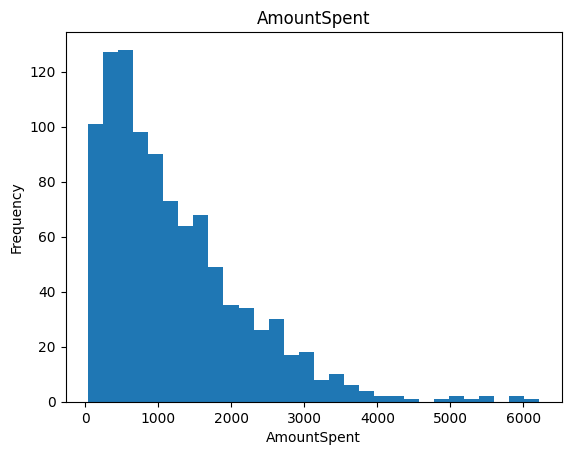

In [19]:
#histogram of AmountSpent 

plt.figure()
plt.hist(df["AmountSpent"], bins=30)
plt.title("AmountSpent")
plt.xlabel("AmountSpent")
plt.ylabel("Frequency")
plt.show()

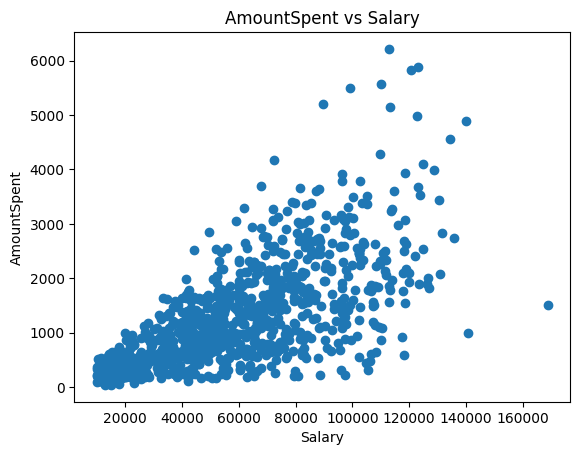

In [20]:
#Salary vs AmountSpent
plt.figure()
plt.scatter(df["Salary"], df["AmountSpent"])
plt.title("AmountSpent vs Salary")
plt.xlabel("Salary")
plt.ylabel("AmountSpent")
plt.show()

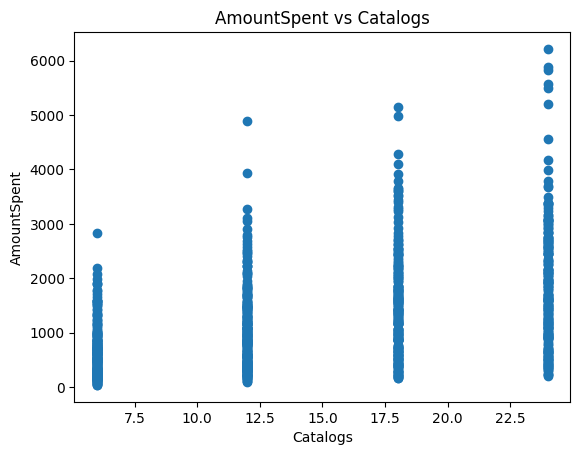

In [21]:
# Catalogs vs AmountSpent
plt.figure()
plt.scatter(df["Catalogs"], df["AmountSpent"])
plt.title("AmountSpent vs Catalogs")
plt.xlabel("Catalogs")
plt.ylabel("AmountSpent")
plt.show()


<Figure size 640x480 with 0 Axes>

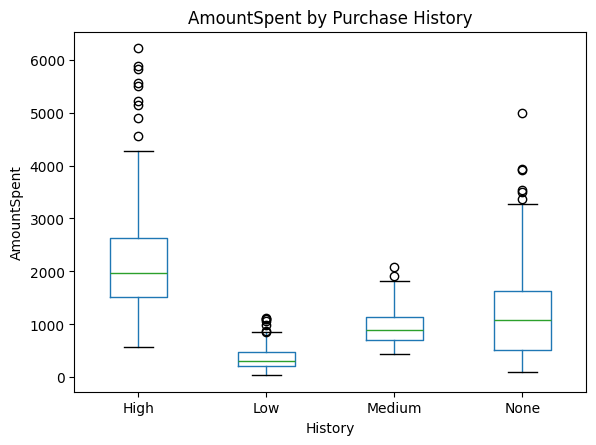

In [22]:
# boxplot of AmountSpent by History
plt.figure()
df.boxplot(column="AmountSpent", by="History", grid=False)
plt.title("AmountSpent by Purchase History")
plt.suptitle("")  # removes default "Boxplot grouped by ..."
plt.xlabel("History")
plt.ylabel("AmountSpent")
plt.show()

In [23]:
df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

print("Data after get_dummies:")
df.astype(float).head()

Data after get_dummies:


,Salary,Children,Catalogs,AmountSpent,Age_Old,Age_Young,Gender_Male,OwnHome_Rent,Married_Single,Location_Far,History_Low,History_Medium,History_None
0,47500.0,0.0,6.0,755.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,63600.0,0.0,6.0,1318.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
2,13500.0,0.0,18.0,296.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
3,85600.0,1.0,18.0,2436.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,68400.0,0.0,12.0,1304.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [24]:
df.corr()['AmountSpent'].sort_values(ascending=False)

AmountSpent       1.000000
Salary            0.699596
Catalogs          0.472650
Location_Far      0.252616
Gender_Male       0.201690
Age_Old           0.113845
History_None      0.015877
History_Medium   -0.143831
Children         -0.222308
OwnHome_Rent     -0.350808
Age_Young        -0.434692
Married_Single   -0.475880
History_Low      -0.489125
Name: AmountSpent, dtype: float64

In [25]:
# Multiple Linear Regression (OLS)
y = df["AmountSpent"].astype(float)
X = df.drop(columns=["AmountSpent"]).astype(float)

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            AmountSpent   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     243.7
Date:                Thu, 30 Apr 2026   Prob (F-statistic):          4.66e-285
Time:                        12:35:59   Log-Likelihood:                -7598.0
No. Observations:                1000   AIC:                         1.522e+04
Df Residuals:                     987   BIC:                         1.529e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           -285.7489    116.394     -2.

In [26]:
robust_model = model.get_robustcov_results(cov_type="HC3")
print(robust_model.summary())


                            OLS Regression Results                            
Dep. Variable:            AmountSpent   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     174.6
Date:                Thu, 30 Apr 2026   Prob (F-statistic):          3.20e-234
Time:                        12:35:59   Log-Likelihood:                -7598.0
No. Observations:                1000   AIC:                         1.522e+04
Df Residuals:                     987   BIC:                         1.529e+04
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           -285.7489    153.513     -1.